In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

np.random.seed(42)
print("환경 설정 완료 (CPU만 사용)")

환경 설정 완료 (CPU만 사용)


In [15]:
def random_pd_matrix(eigenvalues):
    """주어진 eigenvalue를 가진 랜덤 양정치 행렬 생성.
    방법: 랜덤 직교 행렬 Q를 만들고, Q @ diag(eigenvalues) @ Q^T """
    d = len(eigenvalues)
    A = np.random.randn(d, d)
    Q, _ = np.linalg.qr(A)
    return Q @ np.diag(eigenvalues.astype(float)) @ Q.T

# 블록 1: eigenvalues {1, 2, 3}에서 30개 샘플 (완만한 곡률)
eig1 = np.random.choice([1, 2, 3], size=30)
H1 = random_pd_matrix(eig1)

# 블록 2: eigenvalues {99, 100, 101}에서 30개 샘플 (중간 곡률)
eig2 = np.random.choice([99, 100, 101], size=30)
H2 = random_pd_matrix(eig2)

# 블록 3: eigenvalues {4998, 4999, 5000}에서 30개 샘플 (가파른 곡률)
eig3 = np.random.choice([4998, 4999, 5000], size=30)
H3 = random_pd_matrix(eig3)

# 전체 블록 대각 Hessian (90 x 90)
H_full = block_diag(H1, H2, H3)

# 검증
print(f"H_full shape: {H_full.shape}")
print(f"\n블록별 eigenvalue 범위:")
for i, (name, Hb) in enumerate([("Block 1", H1), ("Block 2", H2), ("Block 3", H3)]):
    eigs = np.linalg.eigvalsh(Hb)
    print(f"  {name}: [{eigs.min():.1f}, {eigs.max():.1f}]")

eigs_full = np.linalg.eigvalsh(H_full)
print(f"\n전체 Hessian eigenvalue 범위: [{eigs_full.min():.1f}, {eigs_full.max():.1f}]")
print(f"Condition number: {eigs_full.max() / eigs_full.min():.1f}")

H_full shape: (90, 90)

블록별 eigenvalue 범위:
  Block 1: [1.0, 3.0]
  Block 2: [99.0, 101.0]
  Block 3: [4998.0, 5000.0]

전체 Hessian eigenvalue 범위: [1.0, 5000.0]
Condition number: 5000.0


In [16]:
def gradient_descent(H, w0, lr, num_iters):
    """단일 학습률 GD. lr = 2/(λ_max + λ_min)이 최적."""
    w = w0.copy()
    grad_norms = []
    for _ in range(num_iters):
        g = H @ w
        grad_norms.append(np.linalg.norm(g))
        w = w - lr * g
    return grad_norms

def adam_optimizer(H, w0, lr, num_iters, eps=1e-8):
    """Adam (β₁=0, AdaGrad 스타일).
    논문 Appendix F.2: β₁=0으로 모멘텀 제거, β₂=1로 시간변화 학습률 사용.
    β₂=1의 극한은 AdaGrad (v를 누적합)."""
    w = w0.copy()
    v = np.zeros_like(w)
    grad_norms = []
    for _ in range(num_iters):
        g = H @ w
        grad_norms.append(np.linalg.norm(g))
        v = v + g ** 2                          # AdaGrad 누적
        w = w - lr * g / (np.sqrt(v) + eps)     # coordinate-wise 학습률
    return grad_norms

def blockwise_gd(H_blocks, w0, num_iters):
    """블록별 최적 학습률 GD. 각 블록마다 lr = 2/(λ_max + λ_min)."""
    H_full = block_diag(*H_blocks)
    w = w0.copy()

    # 블록별 최적 학습률 계산
    block_info = []
    idx = 0
    for Hb in H_blocks:
        d = Hb.shape[0]
        eigs = np.linalg.eigvalsh(Hb)
        lr = 2.0 / (eigs.max() + eigs.min())
        block_info.append((idx, idx + d, lr))
        print(f"  블록 [{idx}:{idx+d}] → 최적 lr = {lr:.6f}")
        idx += d

    grad_norms = []
    for _ in range(num_iters):
        g = H_full @ w
        grad_norms.append(np.linalg.norm(g))
        for start, end, lr in block_info:
            w[start:end] -= lr * g[start:end]   # 블록별 다른 학습률

    return grad_norms

print("옵티마이저 정의 완료")
print("  1. gradient_descent: 전체 단일 학습률")
print("  2. adam_optimizer: Adam (β₁=0, AdaGrad 스타일)")
print("  3. blockwise_gd: 블록별 최적 학습률")

옵티마이저 정의 완료
  1. gradient_descent: 전체 단일 학습률
  2. adam_optimizer: Adam (β₁=0, AdaGrad 스타일)
  3. blockwise_gd: 블록별 최적 학습률


In [17]:
# ===== 초기점 설정 =====
d = 90  # 총 차원 (30 + 30 + 30)
w0 = np.random.randn(d)

# ===== 실험 1: 전체 문제 (Figure 4b) =====
print("=" * 50)
print("실험 1: 전체 문제 (90차원)")
print("=" * 50)

num_iters_full = 50000

# (1) 전체 단일 최적 학습률
lr_single = 2.0 / (eigs_full.max() + eigs_full.min())
print(f"\n단일 최적 학습률: {lr_single:.6f}")
norms_single = gradient_descent(H_full, w0, lr_single, num_iters_full)
print(f"  최종 gradient norm: {norms_single[-1]:.2e}")

# (2) Adam
lr_adam = 0.1
print(f"\nAdam 학습률: {lr_adam}")
norms_adam = adam_optimizer(H_full, w0, lr_adam, num_iters_full)
print(f"  최종 gradient norm: {norms_adam[-1]:.2e}")

# (3) 블록별 최적 학습률
print(f"\n블록별 최적 학습률:")
norms_blockwise = blockwise_gd([H1, H2, H3], w0, num_iters_full)
print(f"  최종 gradient norm: {norms_blockwise[-1]:.2e}")

# ===== 실험 2: 서브블록 문제 (Figure 4d) =====
print("\n" + "=" * 50)
print("실험 2: 1번째 서브블록 문제 (30차원)")
print("=" * 50)

num_iters_block = 1000
w0_block = w0[:30].copy()

# (1) 서브블록 최적 단일 학습률
eigs_h1 = np.linalg.eigvalsh(H1)
lr_block = 2.0 / (eigs_h1.max() + eigs_h1.min())
print(f"\n서브블록 단일 최적 학습률: {lr_block:.6f}")
norms_single_block = gradient_descent(H1, w0_block, lr_block, num_iters_block)
print(f"  최종 gradient norm: {norms_single_block[-1]:.2e}")

# (2) Adam (서브블록)
print(f"\nAdam 학습률: {lr_adam}")
norms_adam_block = adam_optimizer(H1, w0_block, lr_adam, num_iters_block)
print(f"  최종 gradient norm: {norms_adam_block[-1]:.2e}")

print("\n모든 실험 완료!")

실험 1: 전체 문제 (90차원)

단일 최적 학습률: 0.000400
  최종 gradient norm: 3.83e-05

Adam 학습률: 0.1
  최종 gradient norm: 3.36e-113

블록별 최적 학습률:
  블록 [0:30] → 최적 lr = 0.500000
  블록 [30:60] → 최적 lr = 0.010000
  블록 [60:90] → 최적 lr = 0.000200
  최종 gradient norm: 0.00e+00

실험 2: 1번째 서브블록 문제 (30차원)

서브블록 단일 최적 학습률: 0.500000
  최종 gradient norm: 0.00e+00

Adam 학습률: 0.1
  최종 gradient norm: 9.22e-03

모든 실험 완료!


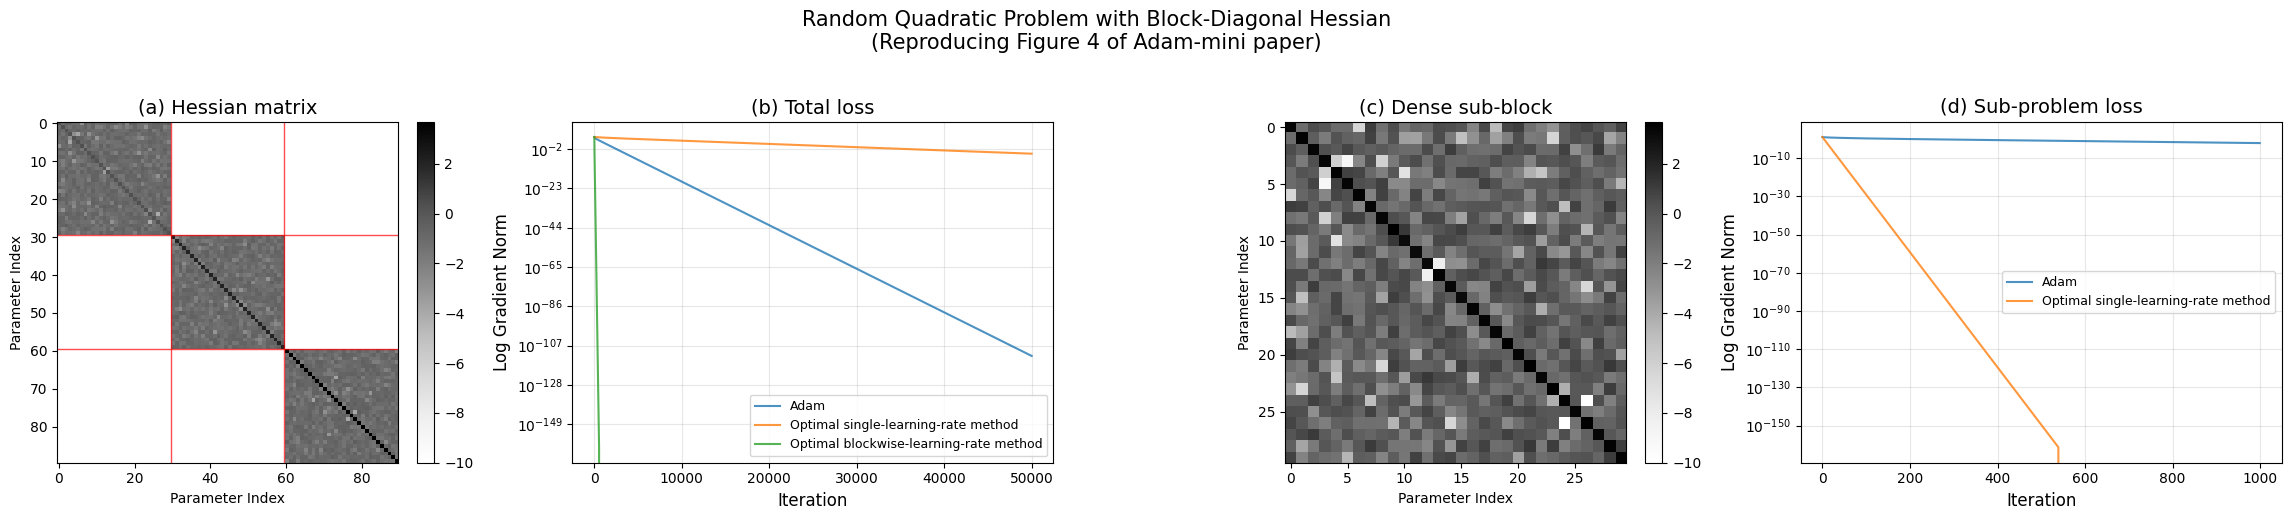

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# ===== (a) 전체 Hessian — 0 아닌 곳만 표시 =====
ax = axes[0]
H_abs = np.abs(H_full)
H_log = np.log10(H_abs + 1e-10)
im = ax.imshow(H_log, cmap='Greys', aspect='equal')
ax.set_title('(a) Hessian matrix', fontsize=14)
ax.set_xlabel('Parameter Index')
ax.set_ylabel('Parameter Index')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for pos in [30, 60]:
    ax.axhline(y=pos - 0.5, color='red', linewidth=1, alpha=0.7)
    ax.axvline(x=pos - 0.5, color='red', linewidth=1, alpha=0.7)

# ===== (b) 전체 문제 학습 곡선 =====
ax = axes[1]
ax.semilogy(norms_adam, label='Adam', linewidth=1.5, alpha=0.8)
ax.semilogy(norms_single, label='Optimal single-learning-rate method',
            linewidth=1.5, alpha=0.8)
ax.semilogy(norms_blockwise, label='Optimal blockwise-learning-rate method',
            linewidth=1.5, alpha=0.8)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Log Gradient Norm', fontsize=12)
ax.set_title('(b) Total loss', fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ===== (c) 서브블록 — log 스케일로 dense 구조 표시 =====
ax = axes[2]
H1_log = np.log10(np.abs(H1) + 1e-10)
ax.imshow(H1_log, cmap='Greys', aspect='equal')
ax.set_title('(c) Dense sub-block', fontsize=14)
ax.set_xlabel('Parameter Index')
ax.set_ylabel('Parameter Index')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ===== (d) 서브블록 문제 학습 곡선 =====
ax = axes[3]
ax.semilogy(norms_adam_block, label='Adam', linewidth=1.5, alpha=0.8)
ax.semilogy(norms_single_block, label='Optimal single-learning-rate method',
            linewidth=1.5, alpha=0.8)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Log Gradient Norm', fontsize=12)
ax.set_title('(d) Sub-problem loss', fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(
    'Random Quadratic Problem with Block-Diagonal Hessian\n'
    '(Reproducing Figure 4 of Adam-mini paper)',
    fontsize=15, y=1.03
)
plt.tight_layout()
plt.savefig('case_study_2_figure4.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print("=" * 60)
print("Case Study 2 결과 분석")
print("=" * 60)

print("""
[논문의 핵심 주장 3가지]

  (1) 전체 문제에서: Adam > 단일 학습률 GD
      → Adam이 coordinate-wise 학습률로 이득을 본다

  (2) 서브블록(dense) 문제에서: 단일 학습률 GD > Adam
      → dense 블록 안에서는 Adam의 coordinate-wise 학습률이 오히려 비효율적

  (3) 블록별 최적 학습률 GD > Adam > 단일 학습률 GD
      → 블록마다 학습률 하나씩만 잘 정해도 Adam보다 빠르다
      → 이것이 Adam-mini의 이론적 근거!
""")

# 정량 비교
print("[우리 실험의 정량 결과]\n")

print("전체 문제 (50000 iterations 후 gradient norm):")
print(f"  Adam:              {norms_adam[-1]:.2e}")
print(f"  단일 최적 학습률:   {norms_single[-1]:.2e}")
print(f"  블록별 최적 학습률: {norms_blockwise[-1]:.2e}")

# 주장 (1) 확인
check1 = norms_adam[-1] < norms_single[-1]
print(f"\n  주장 (1) Adam < 단일 GD: {'✅ 확인' if check1 else '❌ 불일치'}")

# 주장 (3) 확인
check3 = norms_blockwise[-1] < norms_adam[-1]
print(f"  주장 (3) 블록별 GD < Adam: {'✅ 확인' if check3 else '❌ 불일치'}")

print(f"\n서브블록 문제 (1000 iterations 후 gradient norm):")
print(f"  Adam:              {norms_adam_block[-1]:.2e}")
print(f"  단일 최적 학습률:   {norms_single_block[-1]:.2e}")

# 주장 (2) 확인
check2 = norms_single_block[-1] < norms_adam_block[-1]
print(f"\n  주장 (2) 단일 GD < Adam (서브블록): {'✅ 확인' if check2 else '❌ 불일치'}")

print(f"""
[결론]
  블록 대각 Hessian을 가진 문제에서:
  - 전체적으로는 Adam이 단일 GD보다 낫다 (다른 블록에 다른 학습률을 주니까)
  - 그러나 dense 블록 내부에서는 Adam이 비효율적이다
  - 블록마다 학습률 하나씩만 잘 정하면 Adam을 이길 수 있다
  → 이것이 Adam-mini의 핵심 동기!
""")

Case Study 2 결과 분석

[논문의 핵심 주장 3가지]

  (1) 전체 문제에서: Adam > 단일 학습률 GD
      → Adam이 coordinate-wise 학습률로 이득을 본다

  (2) 서브블록(dense) 문제에서: 단일 학습률 GD > Adam
      → dense 블록 안에서는 Adam의 coordinate-wise 학습률이 오히려 비효율적

  (3) 블록별 최적 학습률 GD > Adam > 단일 학습률 GD
      → 블록마다 학습률 하나씩만 잘 정해도 Adam보다 빠르다
      → 이것이 Adam-mini의 이론적 근거!

[우리 실험의 정량 결과]

전체 문제 (50000 iterations 후 gradient norm):
  Adam:              3.36e-113
  단일 최적 학습률:   3.83e-05
  블록별 최적 학습률: 0.00e+00

  주장 (1) Adam < 단일 GD: ✅ 확인
  주장 (3) 블록별 GD < Adam: ✅ 확인

서브블록 문제 (1000 iterations 후 gradient norm):
  Adam:              9.22e-03
  단일 최적 학습률:   0.00e+00

  주장 (2) 단일 GD < Adam (서브블록): ✅ 확인

[결론]
  블록 대각 Hessian을 가진 문제에서:
  - 전체적으로는 Adam이 단일 GD보다 낫다 (다른 블록에 다른 학습률을 주니까)
  - 그러나 dense 블록 내부에서는 Adam이 비효율적이다
  - 블록마다 학습률 하나씩만 잘 정하면 Adam을 이길 수 있다
  → 이것이 Adam-mini의 핵심 동기!

